In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import zoo as g  # the module we've been building; keep it next to this notebook

OUTDIR = Path("out")
OUTDIR.mkdir(exist_ok=True)

PARTICLE_CACHE = OUTDIR / "zoo_cache.pkl"     # simulated particles (x, y, [z] per galaxy)
FRAME_CACHE = OUTDIR / "zoo_frames.pkl"       # rendered face-on/edge-on arrays

In [2]:
# Runs the orbit integrations / Plummer sampling / merger encounters for all
# 10 galaxies (a few minutes) and caches the particles to disk. Re-running
# this cell reuses the cache instead of re-simulating; galaxies missing from
# it, or cached by an older zoo.CACHE_VERSION, are (re)generated.
results = g.load_or_generate(PARTICLE_CACHE)
print(f"{len(results)} galaxies, cache version {g.CACHE_VERSION}")
sorted(results)

10 galaxies, cache version 4


['10_dwarf_irregular',
 '1_grand_design',
 '2_tightly_wound',
 '3_flocculent',
 '4_barred_spiral',
 '5_lenticular',
 '6_elliptical_E0',
 '7_elliptical_E5',
 '8_interacting_pair',
 '9_merger_remnant']

### Physical units and mass budget

Each galaxy has its own unit system (`zoo.PHYS`): code length $L$ and code velocity $V$, with $G=1$, so $t_u = L/V$ and $M_u = V^2 L / G$.

- **Disks.** The disk mass follows from the rotation curve. The disk supplies a fraction `f_disk` of $V_0^2$ at $2.2\,r_d$, which gives $M_d = f_\mathrm{disk} V_0^2\, 2.2 r_d / (0.645\,G)$. The rest is dark matter.
- **Ellipticals.** Self-gravitating Plummer spheres with $V=\sqrt{G M_\star/L}$, so their velocities are consistent with $M_\star$.
- **Mergers.** Each disk's circular speed follows from its mass in the two-body orbit.

Columns of the table below:

| column | meaning |
|---|---|
| `box` | box width |
| `V`, `t_u` | velocity and time units |
| `m_part` | particle mass |
| `M_bary` | particle mass inside the box |
| `M_dyn` | dynamical (total) mass inside `(<r)`, or the whole system |
| `f_b` | `M_bary / M_dyn` |
| `z0` | sech$^2$ scale height |
| `r_s` | scale length used for the profiles: $r_d$, $R_e$ for ellipticals (= Plummer $a$), or the primary's $r_d$ for mergers |
| `age` | integration time |

In [3]:
g.print_mass_budget(g.mass_budget(results))

galaxy                 box     V   t_u      N   m_part   M_bary    M_dyn  (<r)   f_b    z0   r_s   age
                       kpc  km/s   Myr            Msun     Msun     Msun   kpc          pc   kpc   Myr
1_grand_design          20   220    44  59107 1.12e+06 5.91e+10 1.12e+11    10  0.53   350  3.50   400
2_tightly_wound         20   250    39  59707 1.59e+06 7.56e+10 1.44e+11    10  0.52   300  3.50   352
3_flocculent            16   170    46  56420 4.28e+05 2.07e+10 5.34e+10     8  0.39   350  2.80   414
4_barred_spiral         20   220    44  59899 1.23e+06 6.54e+10 1.12e+11    10  0.58   350  3.50   400
5_lenticular            16   230    34  60000 1.17e+06 5.80e+10 9.78e+10     8  0.59   500  2.80   306
6_elliptical_E0         20   254    38  40000 3.73e+06 1.40e+11 1.50e+11   all  0.94     -  3.00     0
7_elliptical_E5         20   185    53  40000 1.99e+06 7.72e+10 8.00e+10   all  0.97     -  3.00     0
8_interacting_pair      60   220    44  26997 3.32e+06 8.64e+10 5.06e+11 

In [4]:
# For each galaxy, builds the SPH, uniform-grid and pseudo-AMR yt datasets
# (density only, which is all the montages need) from the cached particles
# and extracts face-on / edge-on density slices and projections. Also a few
# minutes; incrementally cached to FRAME_CACHE so a crash doesn't lose
# progress and re-running this cell is instant once done. Frames from an
# older zoo.CACHE_VERSION are re-rendered.
try:
    with open(FRAME_CACHE, "rb") as f:
        frames = pickle.load(f)
except (FileNotFoundError, EOFError):
    frames = {}

for name in g.ORDER:
    if frames.get(name, {}).get("version") == g.CACHE_VERSION:
        continue
    frames[name] = g.render_galaxy(name, results[name], outdir=str(OUTDIR))
    print(name, "AMR:", frames[name]["amr_info"])
    with open(FRAME_CACHE, "wb") as f:
        pickle.dump(frames, f)

print(f"rendered {len(frames)} galaxies")

6_elliptical_E0 AMR: {'n_grids': 2845, 'grids_per_level': [1, 1568, 350, 874, 52], 'finest_cell_pc': 78.1}


7_elliptical_E5 AMR: {'n_grids': 2630, 'grids_per_level': [1, 1568, 353, 656, 52], 'finest_cell_pc': 78.1}


rendered 10 galaxies


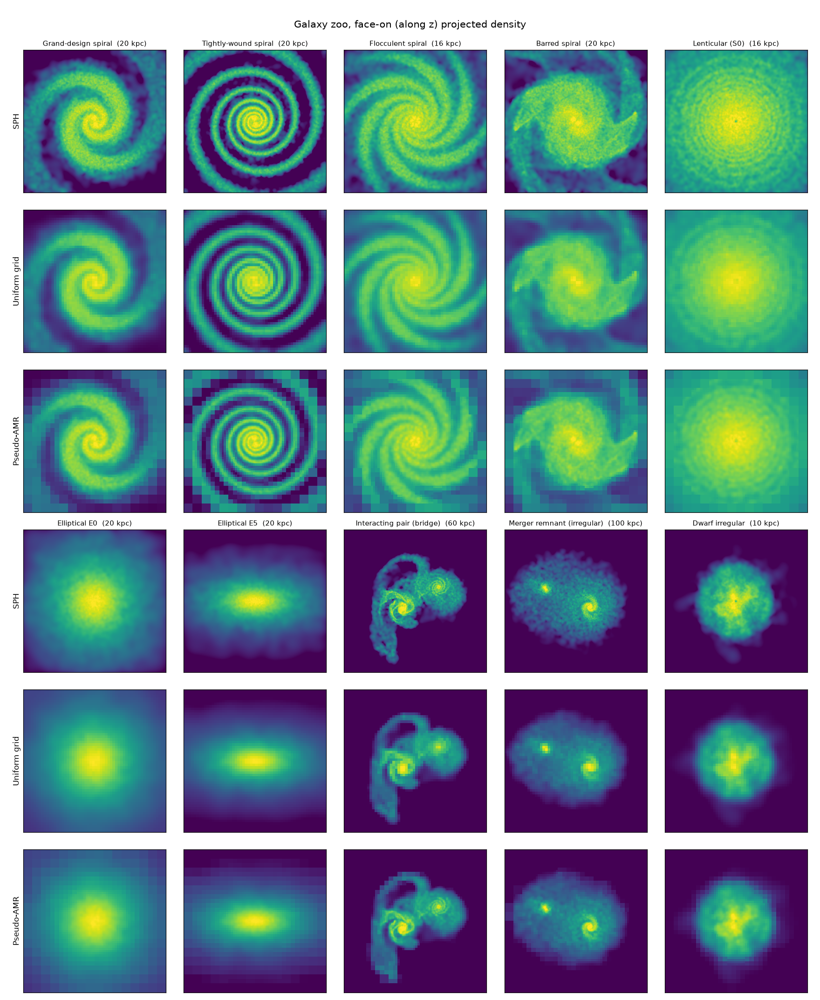

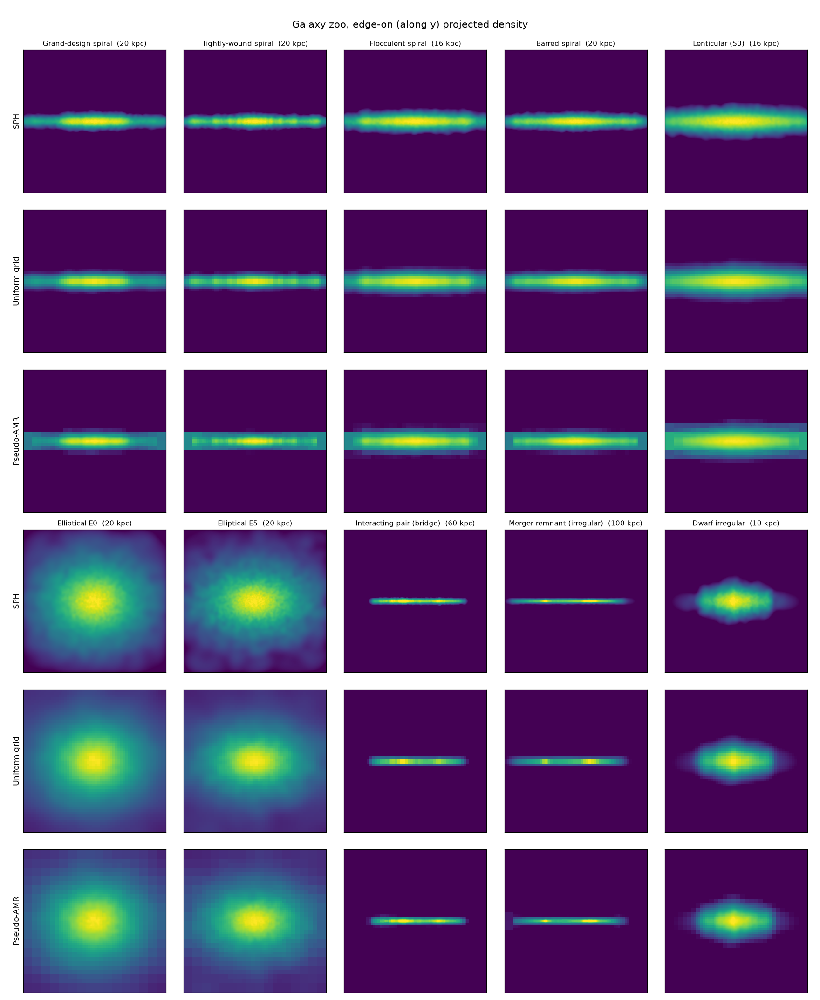

In [5]:
# Both montages (rows = SPH / uniform / AMR, one color scale per galaxy per
# view) are written straight from the cached slices in `frames` -- no yt or
# simulation calls happen here, so re-running this cell after tweaking
# dyn_range, e.g., is instant.
g.make_montages(frames, kind="proj", outdir=str(OUTDIR), dyn_range=3.0)

from IPython.display import Image, display
display(Image(filename=str(OUTDIR / "zoo_montage_faceon_proj.png")))
display(Image(filename=str(OUTDIR / "zoo_montage_edgeon_proj.png")))

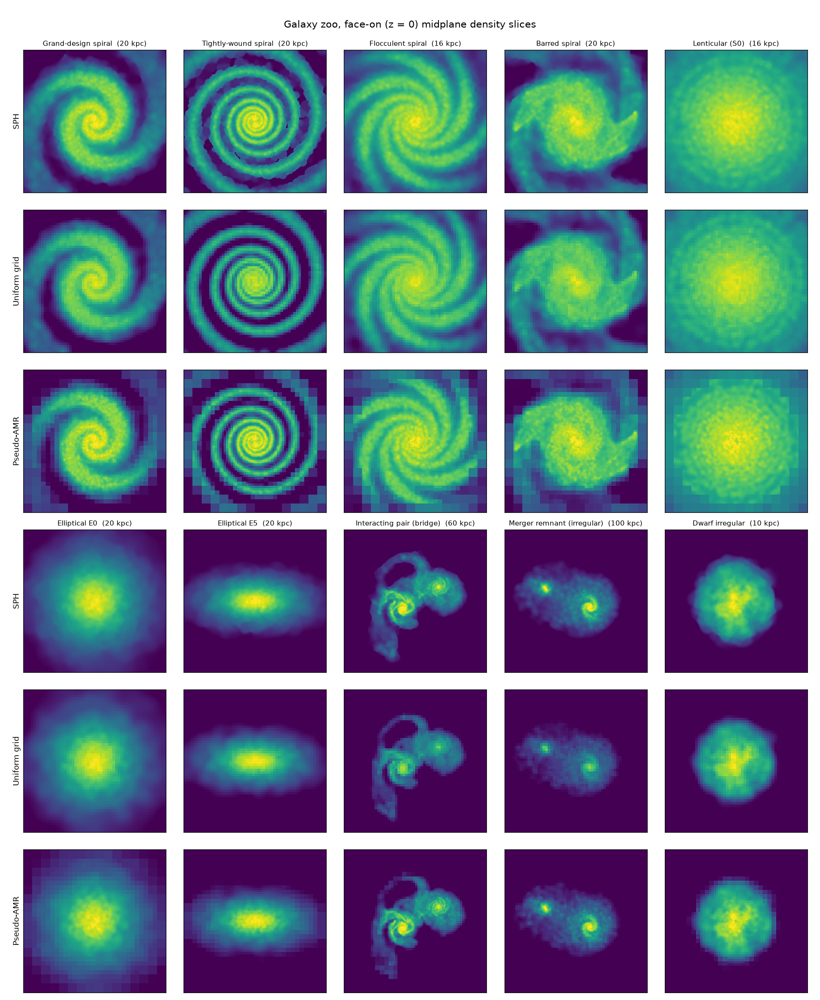

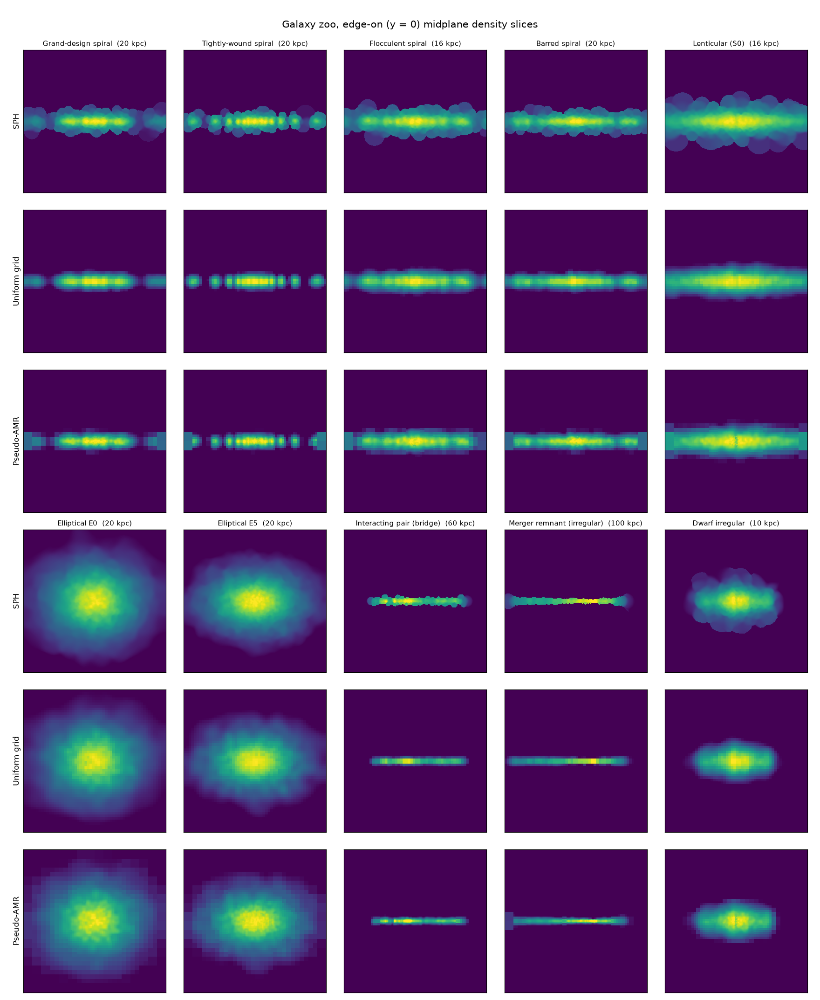

In [6]:
# Both montages (rows = SPH / uniform / AMR, one color scale per galaxy per
# view) are written straight from the cached slices in `frames` -- no yt or
# simulation calls happen here, so re-running this cell after tweaking
# dyn_range, e.g., is instant.
g.make_montages(frames, kind="slic", outdir=str(OUTDIR), dyn_range=3.0)

from IPython.display import Image, display
display(Image(filename=str(OUTDIR / "zoo_montage_faceon_slic.png")))
display(Image(filename=str(OUTDIR / "zoo_montage_edgeon_slic.png")))

## yt experiments: density, pressure, velocity and temperature

The yt datasets built by `g.build_ds(gal, method)` (`"sph"`, `"uniform"`, `"amr"`) carry these fields natively:
- `("gas", "density")`
- `("gas", "velocity_x/y/z")`, plus everything yt derives from them (`velocity_magnitude`, `velocity_cylindrical_theta`, ...)
- `("gas", "temperature")`
- `("gas", "pressure")`

All of them are in physical units.

**Thermodynamics is kinetic.** Every particle's 1D velocity dispersion $\sigma^2$ is measured over its 32 nearest neighbours, after removing a local linear flow fit (bulk motion, rotation and shear). Then
$$T = \mu m_p \sigma^2 / k_B \quad (\mu = 0.6), \qquad P = \rho\,\sigma^2,$$
so $P = \rho k_B T/(\mu m_p)$ holds exactly. The grids deposit mass, momentum and $m\sigma^2$ with one shared adaptive kernel, then form $v = p/m$ and $\sigma^2 = E/m$ per cell. Mass and momentum are therefore conserved across all AMR levels.

**Disk velocities are a kinematic model** on top of the simulated positions. The strong spiral and bar forcing that makes the arms by orbit crowding leaves the integrated test-particle velocities unphysically hot: mean $v_\phi \approx 0.3\,V_0$ and $\sigma \approx 0.6\,V_0$. The model has three parts:
- **Ordered flow:** the circular speed of the potential.
- **Arm streaming:** a $v_\phi$ deficit and radial inflow proportional to $\tanh$ of the local density contrast, of about 10% of $v_c$.
- **Random motion:** isotropic, with $\sigma^2 = \pi G \Sigma z_0$. This is the isothermal sheet that matches the sech$^2(z/z_0)$ thickness, i.e. vertical hydrostatic equilibrium.

Merger tidal debris follows its simulated (neighbour-smoothed) bulk flow. The ellipticals use velocities sampled from the isotropic Plummer distribution function.

**Reading the maps:**
- Slices are at the midplane (face-on) or at $y=0$ (edge-on).
- Projections show column density, and density-weighted averages for the intensive fields.
- **|v| differs between representations:** a grid cell holds the mass-weighted *mean* velocity, so it shows only the ordered flow. SPH smooths the particle velocities with the kernel, which keeps some of the random motion, especially where particles are sparse. The radial profiles show the same difference: the SPH profile averages per-particle $|v| \approx \sqrt{v_c^2 + 3\sigma^2}$.

In [7]:
plt.rcParams["figure.dpi"] = 80  # keeps the notebook size reasonable
FIELD_RES = 384                  # pixels across the box for the field maps


def field_maps(name, gal, dsets):
    """Face-on / edge-on slices and projections of density, pressure, |v| and
    T for the three representations; figures saved to out/ and shown."""
    imgs = {m: {k: g.field_images(dsets[m], gal, k, res=FIELD_RES) for k in g.KINDS}
            for m in g.METHODS}
    for kind in g.KINDS:
        for view in ("face", "edge"):
            fig = g.plot_field_grid({m: imgs[m][kind] for m in g.METHODS}, gal, view, kind)
            fig.savefig(OUTDIR / f"fields_{name}_{view}on_{kind}.png", dpi=110)
            plt.show()
    return imgs


def profiles(name, gal, dsets):
    """Radial profiles around each nucleus, one line per representation."""
    out = []
    for i, (c, rs, label) in enumerate(g.profile_targets(gal)):
        prof = {m: g.radial_profiles(dsets[m], gal, center=c, r_scale_kpc=rs) for m in g.METHODS}
        fig = g.plot_profiles(prof, gal, label)
        fig.savefig(OUTDIR / f"profiles_{name}{'_' + str(i + 1) if label else ''}.png", dpi=110)
        plt.show()
        out.append(prof)
    return out

### Grand-design spiral (`1_grand_design`)

**What to look for**
- **Density and pressure:** the two arms are density *and* pressure ridges. The pressure contrast is larger than the density contrast, since $P=\rho\sigma^2$ and $\sigma^2 \propto \Sigma$.
- **|v|:** nearly featureless at $\approx v_c$, with the arm streaming showing up as slightly slower arms. In the edge-on view, |v| traces the flat rotation curve.
- **Temperature:** falls outward with the surface density, from $\sim 10^{5.8}$ K in the centre to $\sim 10^{4.5}$ K at $3\,r_d$. Hydrostatic support of a $z_0 = 350$ pc disk of $\sim 6\times10^{10}\,M_\odot$ needs $\sigma \sim 20$–$90$ km/s, which is stellar-like, warm–hot.
- **Profiles:** $v_\phi$ rises and flattens at $V \approx 210$ km/s. The enclosed particle mass stays below the dynamical mass, and the gap is the dark matter.

AMR: {'n_grids': 4149, 'grids_per_level': [1, 880, 202, 642, 1970, 454], 'finest_cell_pc': 39.1}


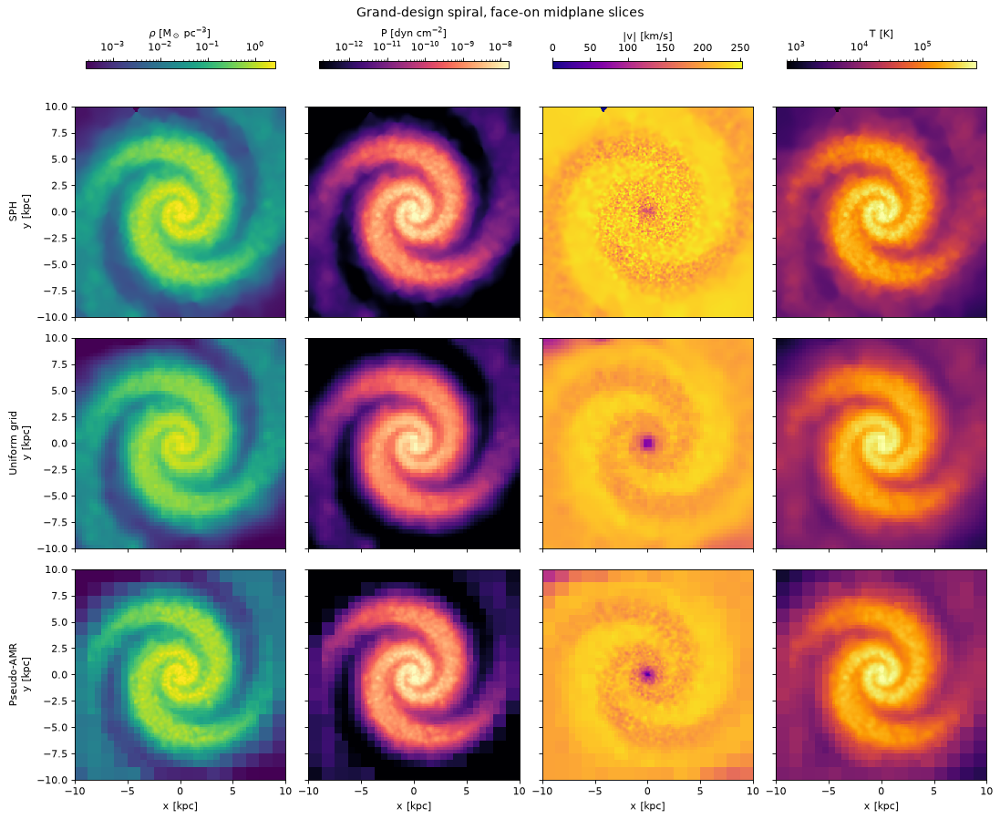

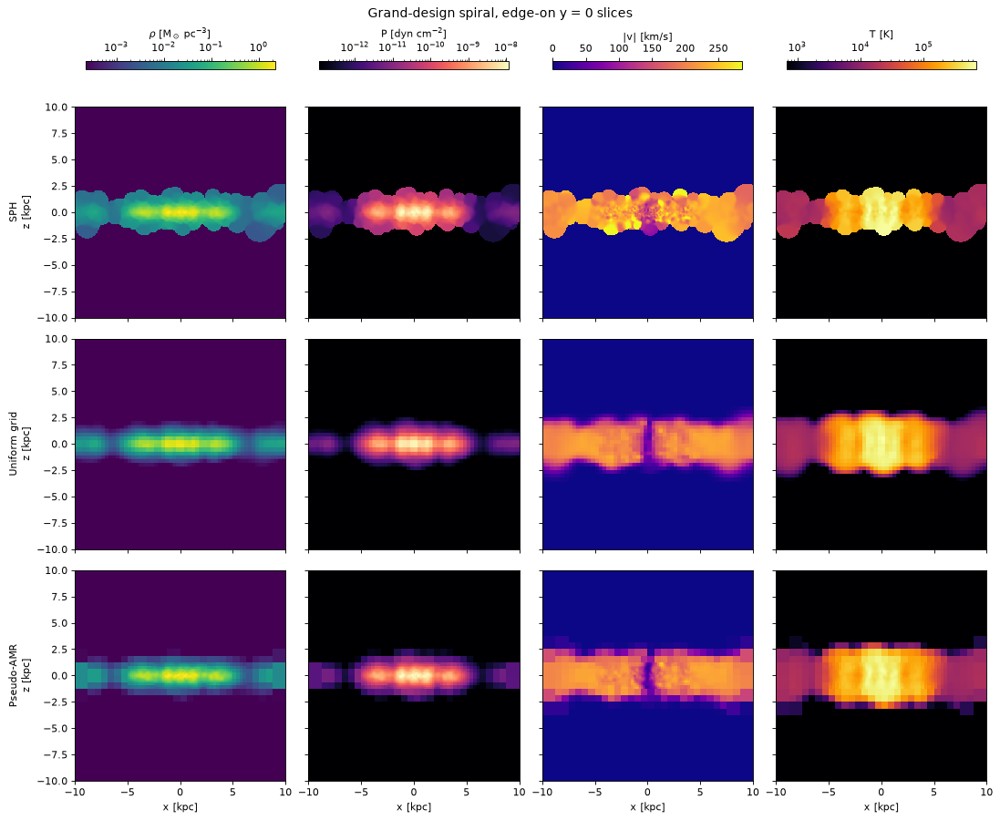

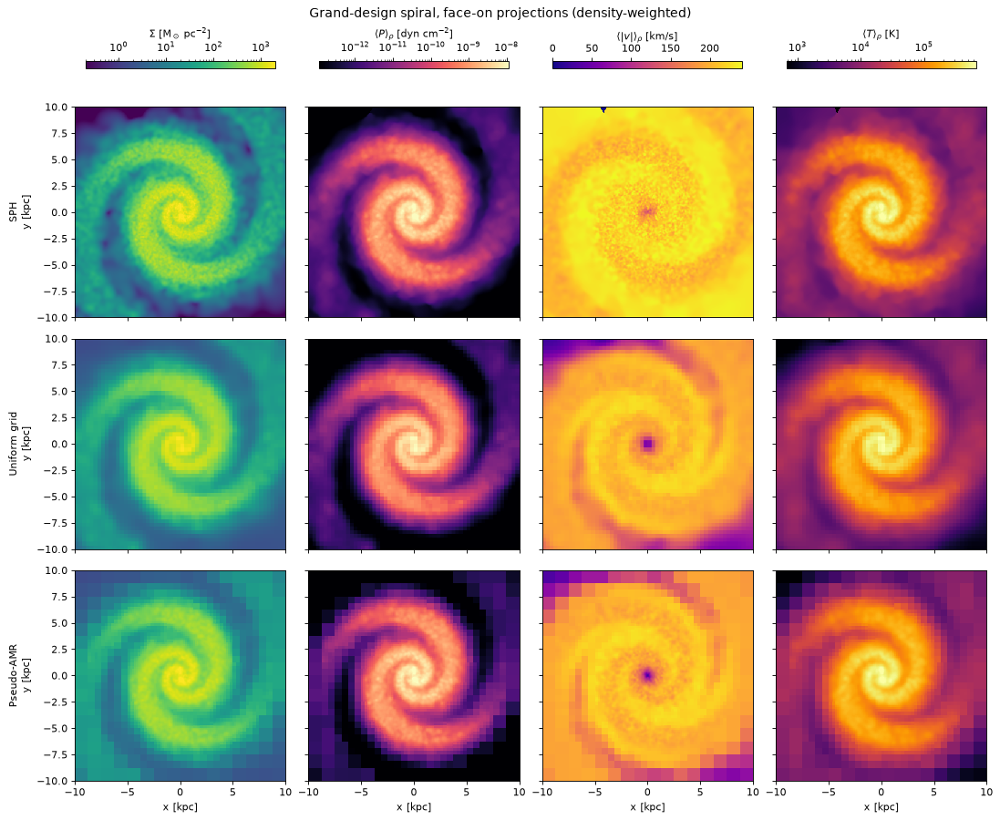

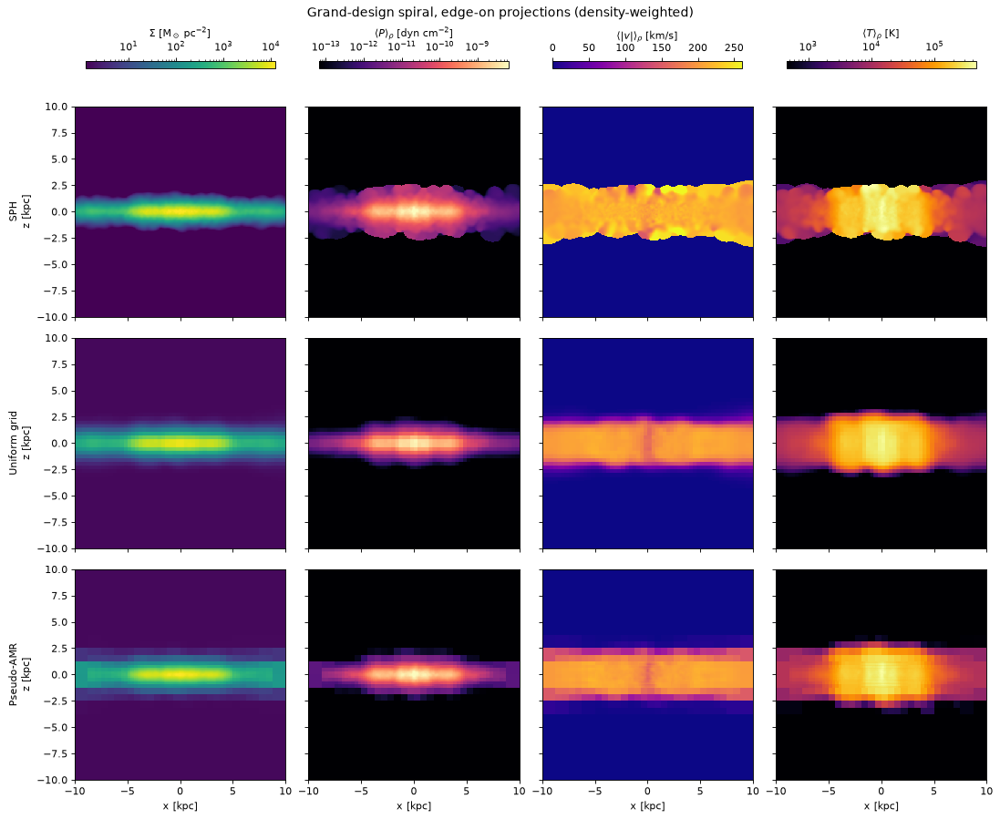

In [8]:
name = "1_grand_design"
gal = g.prepare_galaxy(name, results[name])
dsets = {}
for method in g.METHODS:
    dsets[method], info = g.build_ds(gal, method)  # density, velocity, T, P
    if info:
        print("AMR:", info)
imgs = field_maps(name, gal, dsets)


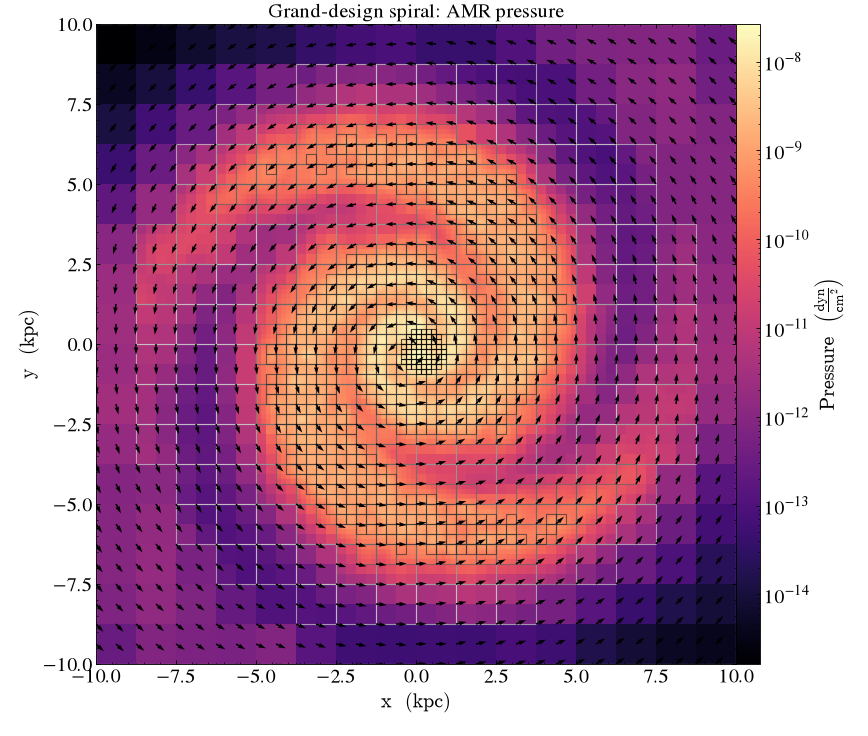

In [9]:
# native yt: AMR pressure slice with grid outlines and velocity arrows
g.yt_plot(dsets["amr"], "z", "slic", field="pressure", grids=True, velocity=True,
          title=f"{gal['title']}: AMR pressure")

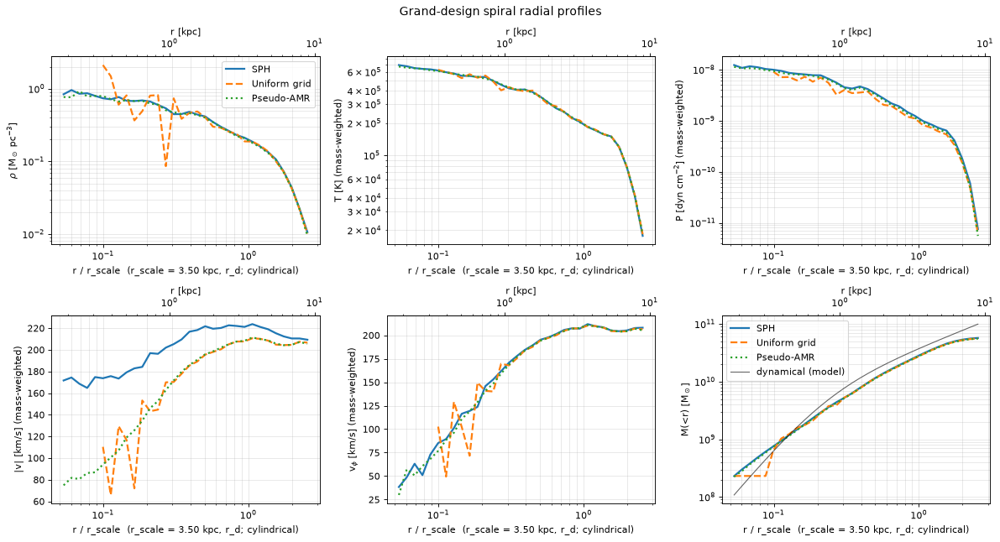

In [10]:
profs = profiles(name, gal, dsets)
del dsets

### Merger remnant (`9_merger_remnant`)

**What to look for**
- **Nuclei:** the two nuclei are still separate, about 30 kpc apart, in a common envelope of tidal debris.
- **Pressure:** pressure peaks sit on the nuclei; the debris is at low pressure.
- **Temperature:** high in the compact nuclear disks. In the debris it is set by the low $\Sigma$ there plus the shear left in the simulated flow.
- **|v|:** the |v| maps show the orbital motion of the nuclei and the streaming of the tidal material.
- **Profiles:** made around each nucleus, each scaled by its own disk's $r_d$. Coarse grids in the 100 kpc box leave the innermost uniform and AMR bins empty. Compare the finest-cell size in the AMR summary above.
- **Resolution effect:** the uniform-grid cells (1.8 kpc) are much thicker than the 350 pc disk. This dilutes $\rho$, and with it the mass-weighted $P=\rho\sigma^2$, by a factor of a few relative to SPH. $T$, which depends only on $\sigma^2$, is unaffected.

AMR: {'n_grids': 2091, 'grids_per_level': [1, 880, 202, 320, 320, 368], 'finest_cell_pc': 195.3}


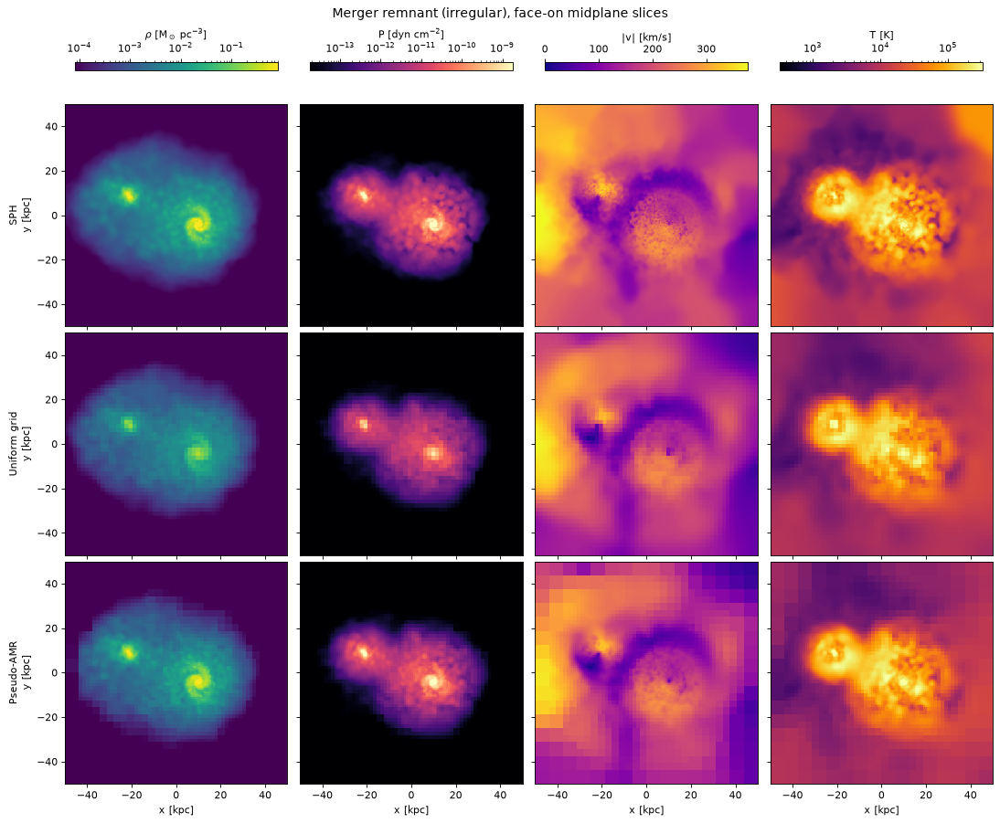

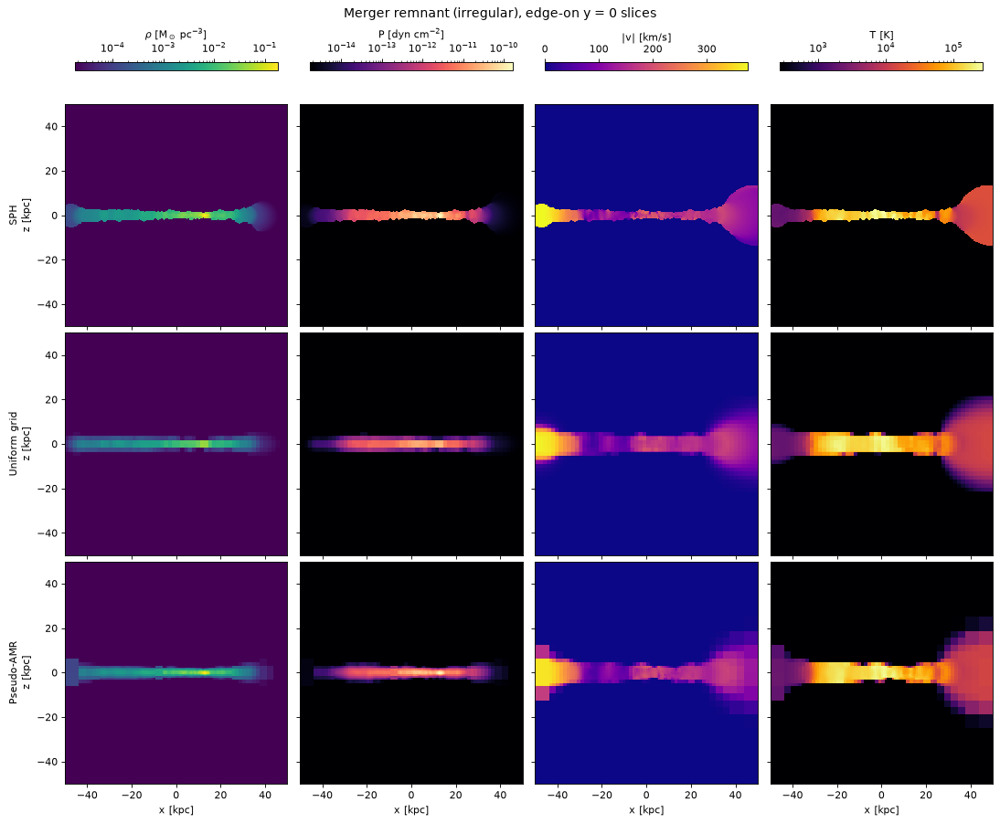

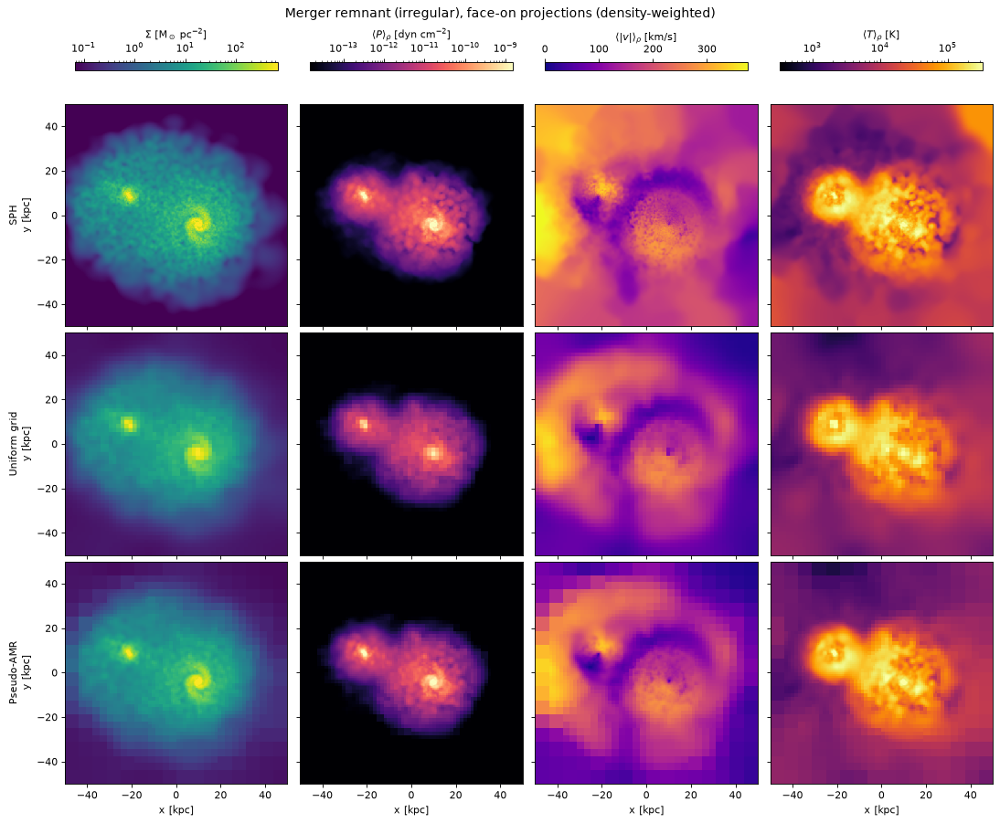

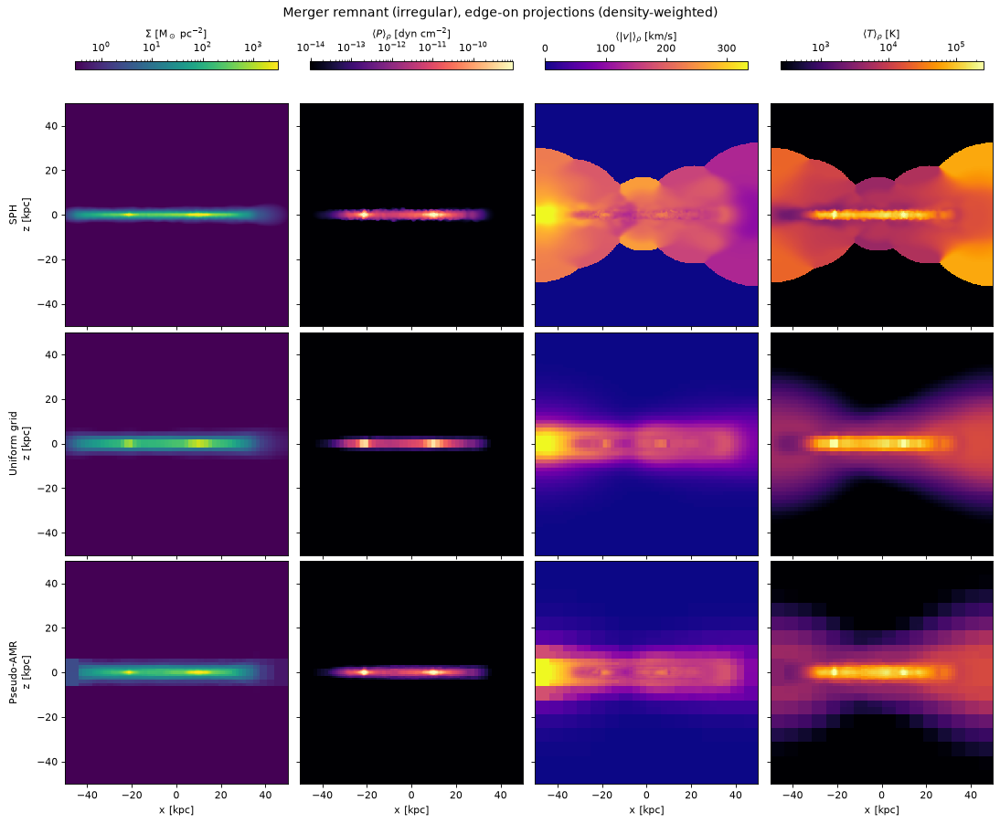

In [11]:
name = "9_merger_remnant"
gal = g.prepare_galaxy(name, results[name])
dsets = {}
for method in g.METHODS:
    dsets[method], info = g.build_ds(gal, method)  # density, velocity, T, P
    if info:
        print("AMR:", info)
imgs = field_maps(name, gal, dsets)


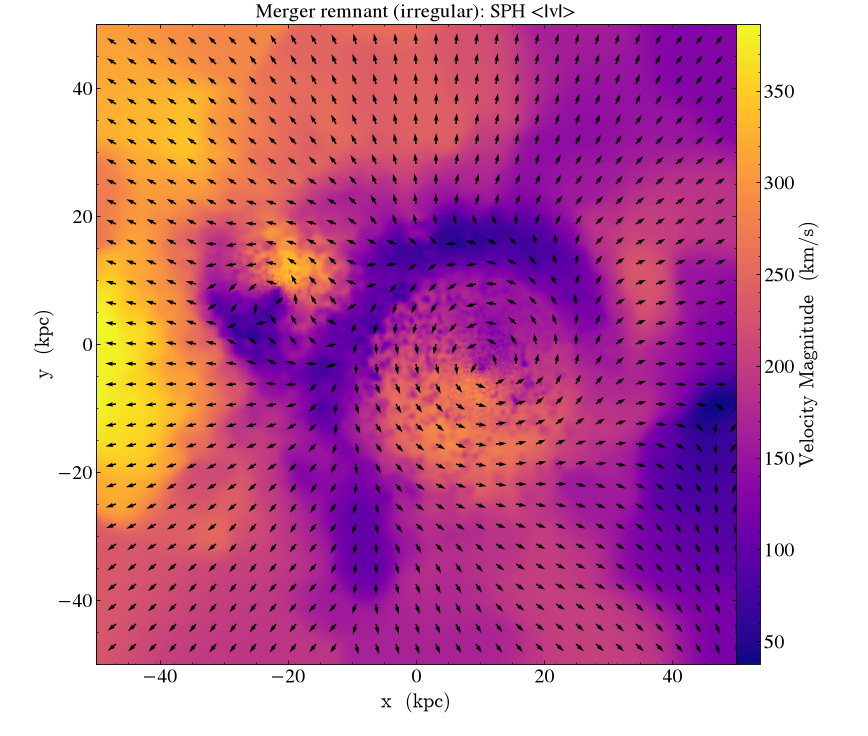

In [12]:
# native yt: SPH density-weighted |v| projection with velocity arrows
g.yt_plot(dsets["sph"], "z", "proj", field="velocity_magnitude", velocity=True,
          title=f"{gal['title']}: SPH <|v|>")

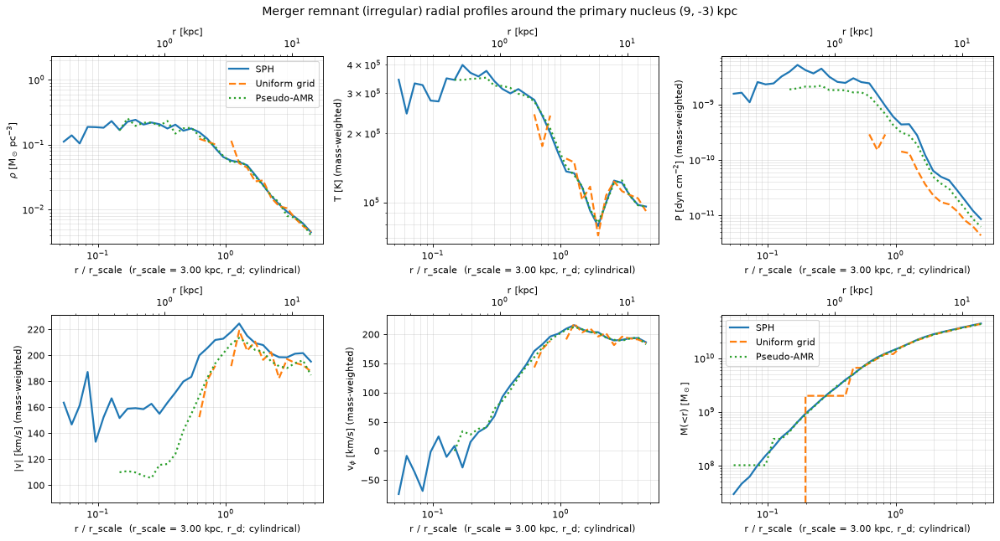

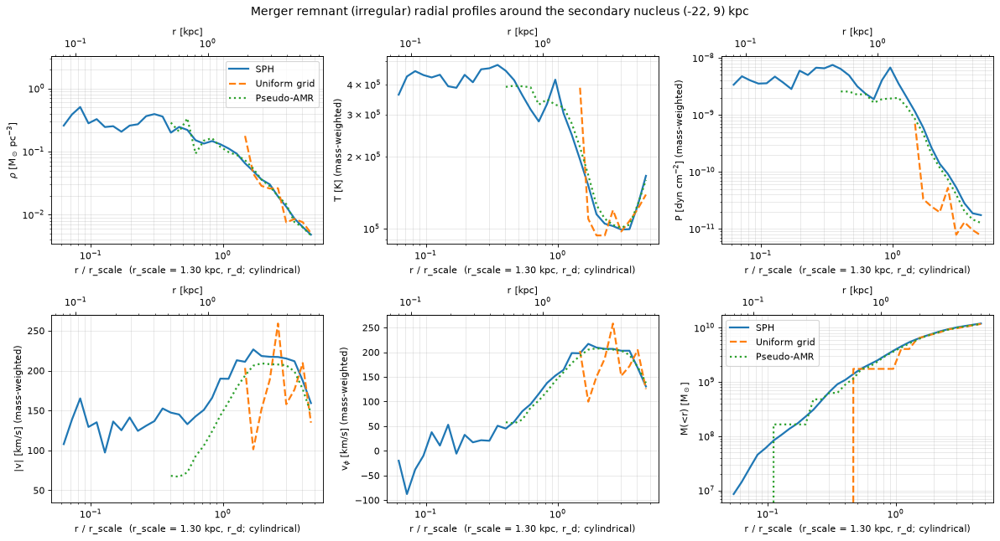

In [13]:
profs = profiles(name, gal, dsets)
del dsets

### Elliptical E0 (`6_elliptical_E0`)

**What to look for**
- **Velocity:** a pressure-supported spheroid, with no ordered rotation. The grid |v| maps show only small-scale noise from the mean of random velocities, while SPH keeps some of the random motion.
- **Temperature:** $\sigma \approx 190$ km/s in the centre gives $T \approx 2\times10^6$ K, about the virial temperature of a $1.5\times10^{11}\,M_\odot$ elliptical, comparable to real X-ray coronae. $T$ falls slowly outward, as for a nearly isothermal Plummer core.
- **Pressure:** $P$ follows $\rho$ closely.
- **Profiles:** use the spherical radius in units of $R_e$ (= Plummer $a$, projected half-mass radius). $v_r \approx 0$ shows the equilibrium, and $M(<r)$ follows the Plummer model.

AMR: {'n_grids': 2845, 'grids_per_level': [1, 1568, 350, 874, 52], 'finest_cell_pc': 78.1}


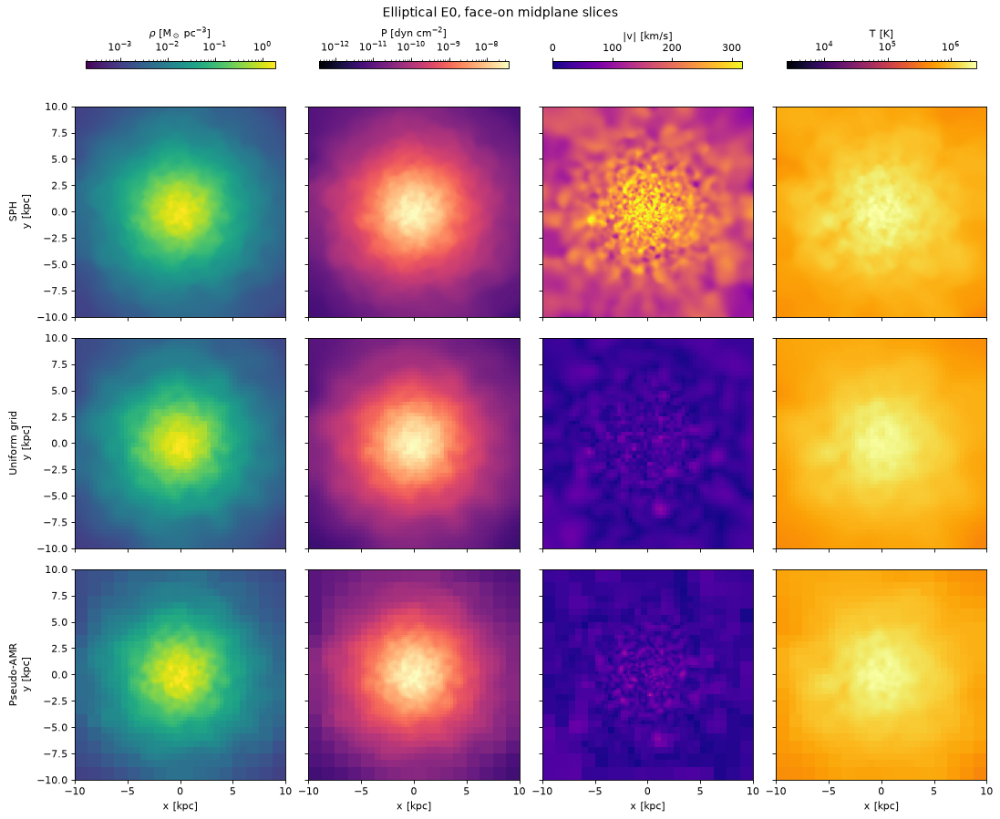

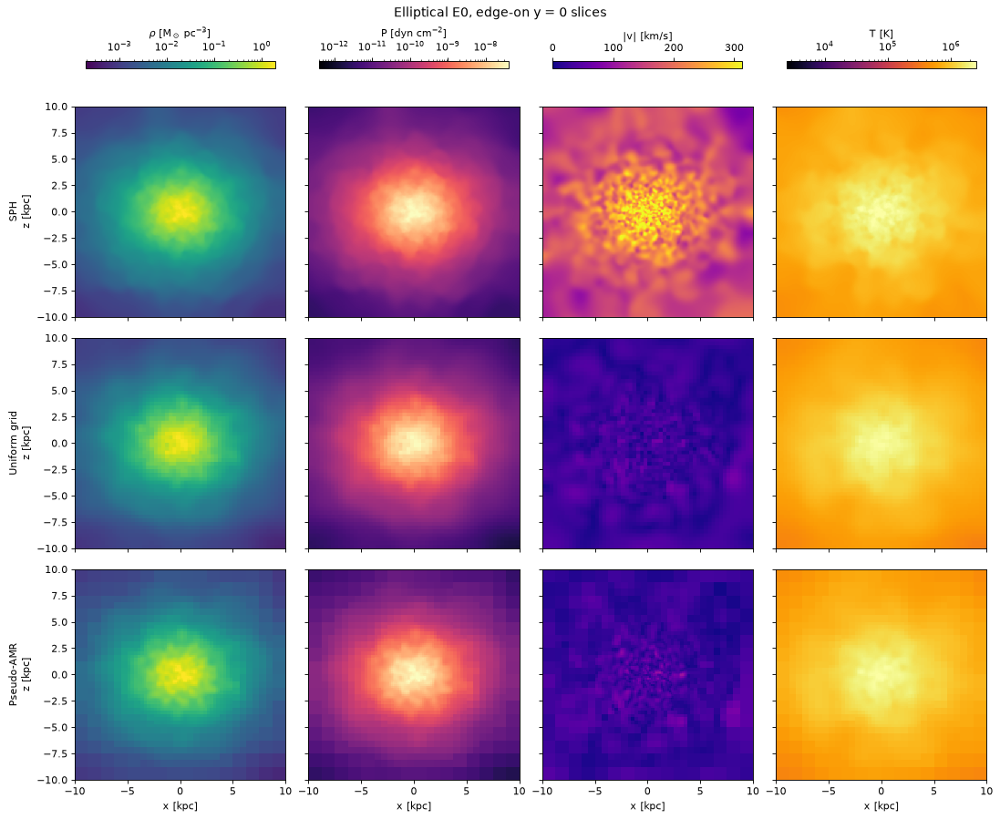

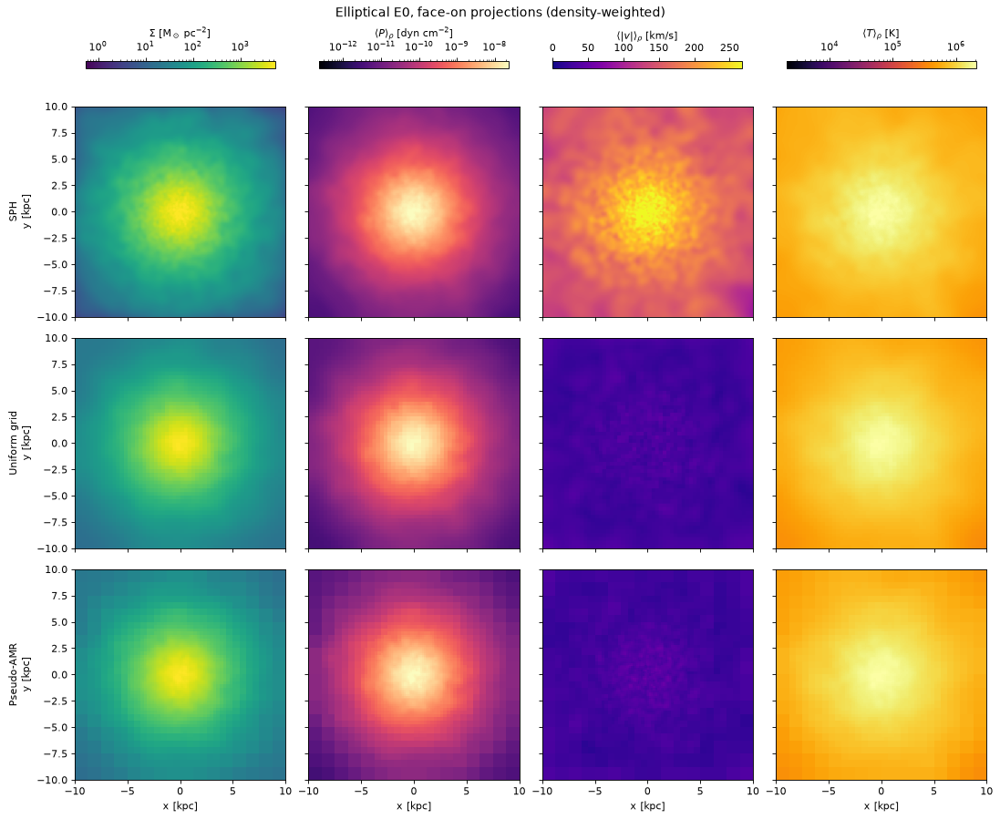

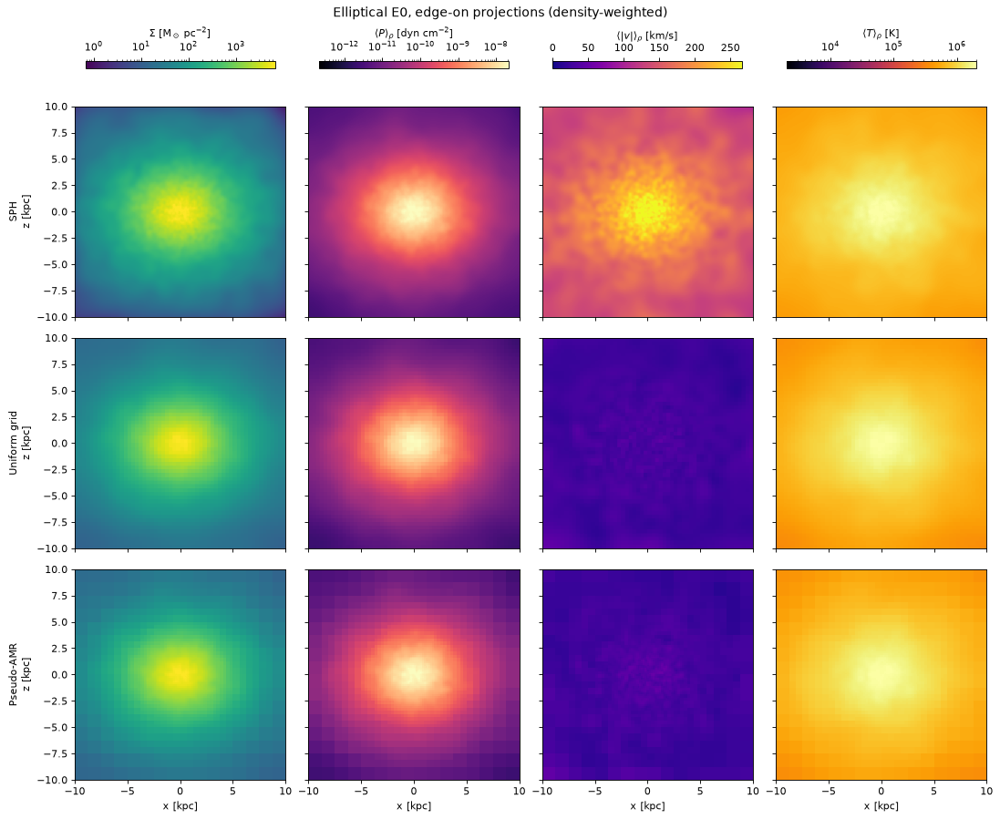

In [14]:
name = "6_elliptical_E0"
gal = g.prepare_galaxy(name, results[name])
dsets = {}
for method in g.METHODS:
    dsets[method], info = g.build_ds(gal, method)  # density, velocity, T, P
    if info:
        print("AMR:", info)
imgs = field_maps(name, gal, dsets)


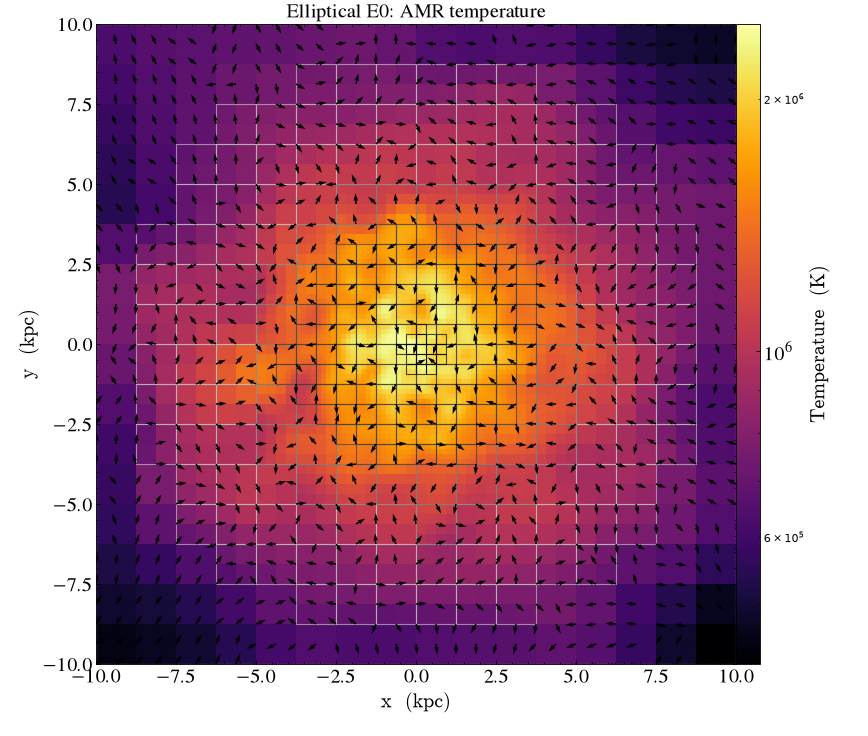

In [15]:
# native yt: AMR temperature slice with grid outlines and velocity arrows
g.yt_plot(dsets["amr"], "z", "slic", field="temperature", grids=True, velocity=True,
          title=f"{gal['title']}: AMR temperature")

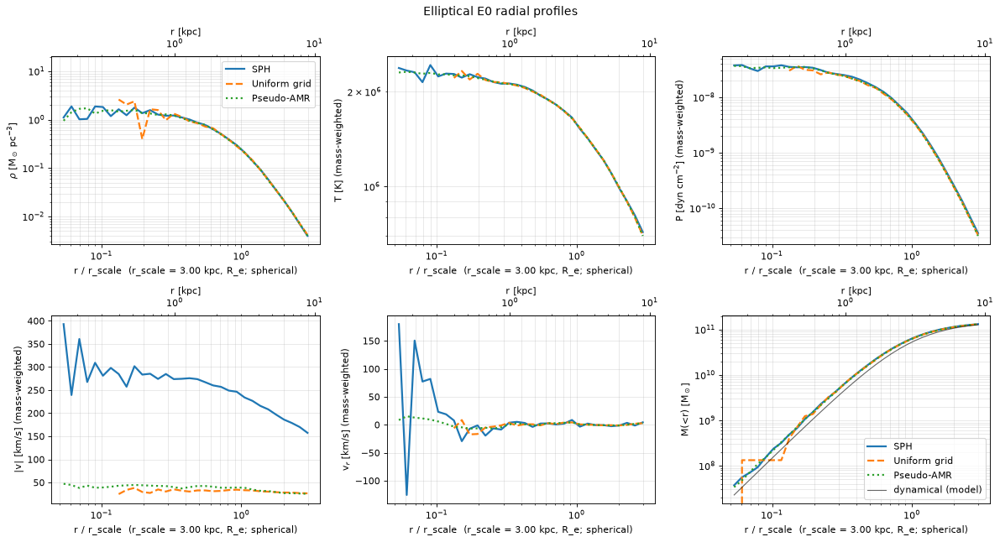

In [16]:
profs = profiles(name, gal, dsets)
del dsets